# 1. Исследование данных

Первые 5 строк датасета
                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000

Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7),

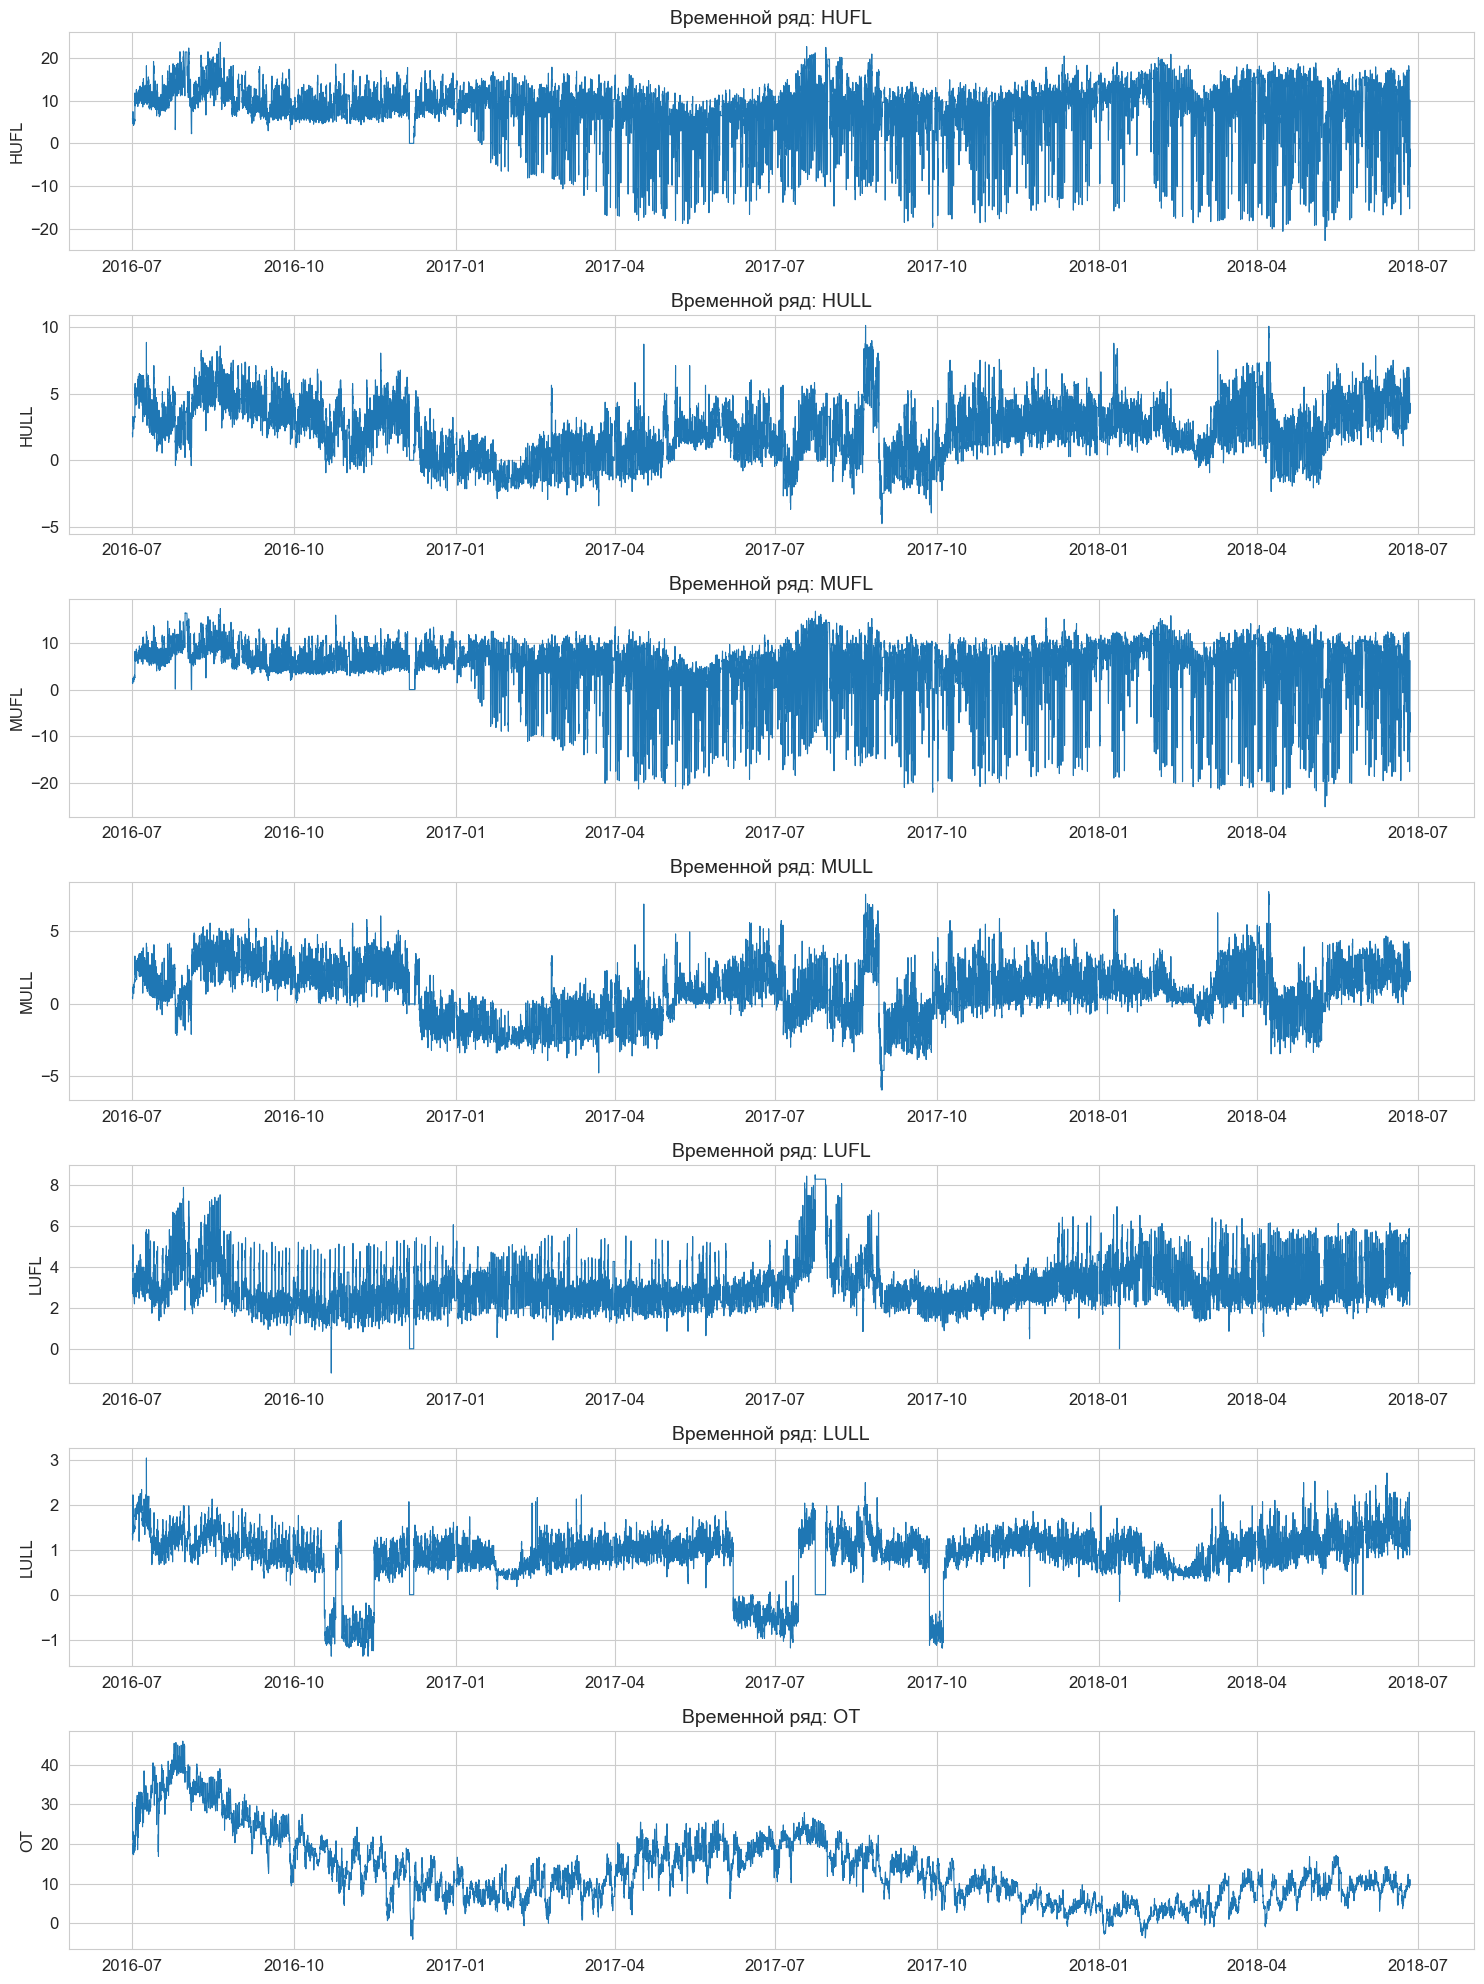

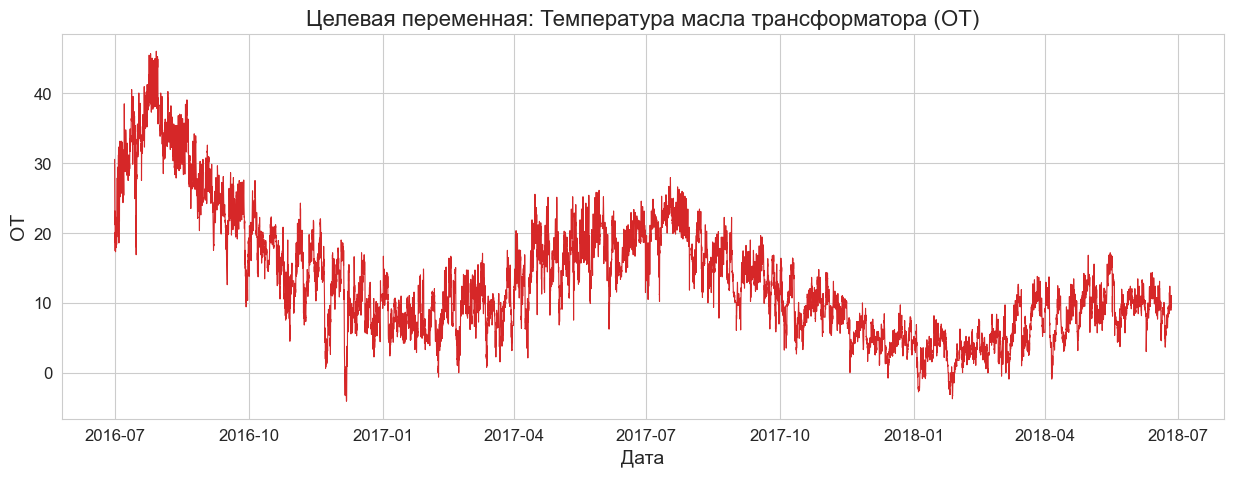

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка размера графиков
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# 1. Загрузка данных
df = pd.read_csv('data_for_ikm/ETTh1.csv')

# 2. Первичный осмотр
print("Первые 5 строк датасета")
print(df.head())

print("\nИнформация о датасете")
print(df.info())

# 3. Преобразование даты
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# 4. Визуализация всех признаков
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(15, 20))
features = df.columns.tolist()

for i, feature in enumerate(features):
    axes[i].plot(df.index, df[feature], color='tab:blue', linewidth=0.8)
    axes[i].set_title(f'Временной ряд: {feature}', fontsize=14)
    axes[i].set_ylabel(feature, fontsize=12)

plt.tight_layout()
plt.show()

# 5. Детальный график целевой переменной OT
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['OT'], color='tab:red', linewidth=0.8)
plt.title('Целевая переменная: Температура масла трансформатора (OT)', fontsize=16)
plt.ylabel('OT', fontsize=14)
plt.xlabel('Дата', fontsize=14)
plt.show()

In [ ]:
print("\nБазовая статистика")
print(df.describe())


Базовая статистика
               HUFL          HULL          MUFL          MULL          LUFL  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean       7.375141      2.242242      4.300239      0.881568      3.066062   
std        7.067744      2.042342      6.826978      1.809293      1.164506   
min      -22.705999     -4.756000    -25.087999     -5.934000     -1.188000   
25%        5.827000      0.737000      3.296000     -0.284000      2.315000   
50%        8.774000      2.210000      5.970000      0.959000      2.833000   
75%       11.788000      3.684000      8.635000      2.203000      3.625000   
max       23.643999     10.114000     17.341000      7.747000      8.498000   

               LULL            OT  
count  17420.000000  17420.000000  
mean       0.856932     13.324672  
std        0.599552      8.566946  
min       -1.371000     -4.080000  
25%        0.670000      6.964000  
50%        0.975000     11.396000  
75%        1.218

# Основные выводы
1. Нет ярко выраженного тренда
2. Можно заметить гетероскедастичность (Изменение дисперсии со временем) у признаков LUFL, MUFL, HULL, HUFL.
3. Видны аномалии (около середины LULL,LUFL,MUFL,HULL)

# 2.1 Предобработка и подробный анализ

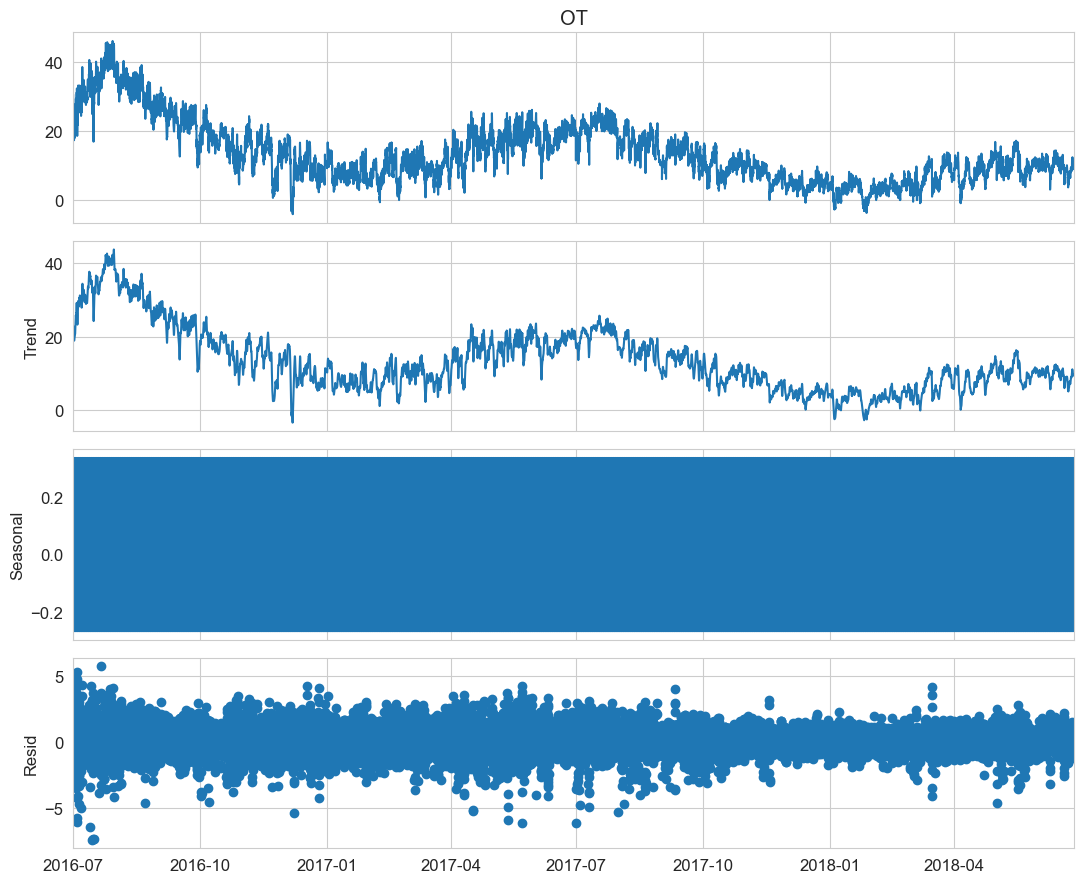

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

from pylab import rcParams
rcParams['figure.figsize'] = 11, 9


decompose = seasonal_decompose(df["OT"], period=12)
decompose.plot()
plt.show()

 Анализ 3 недельных срезов для целевой переменной OT


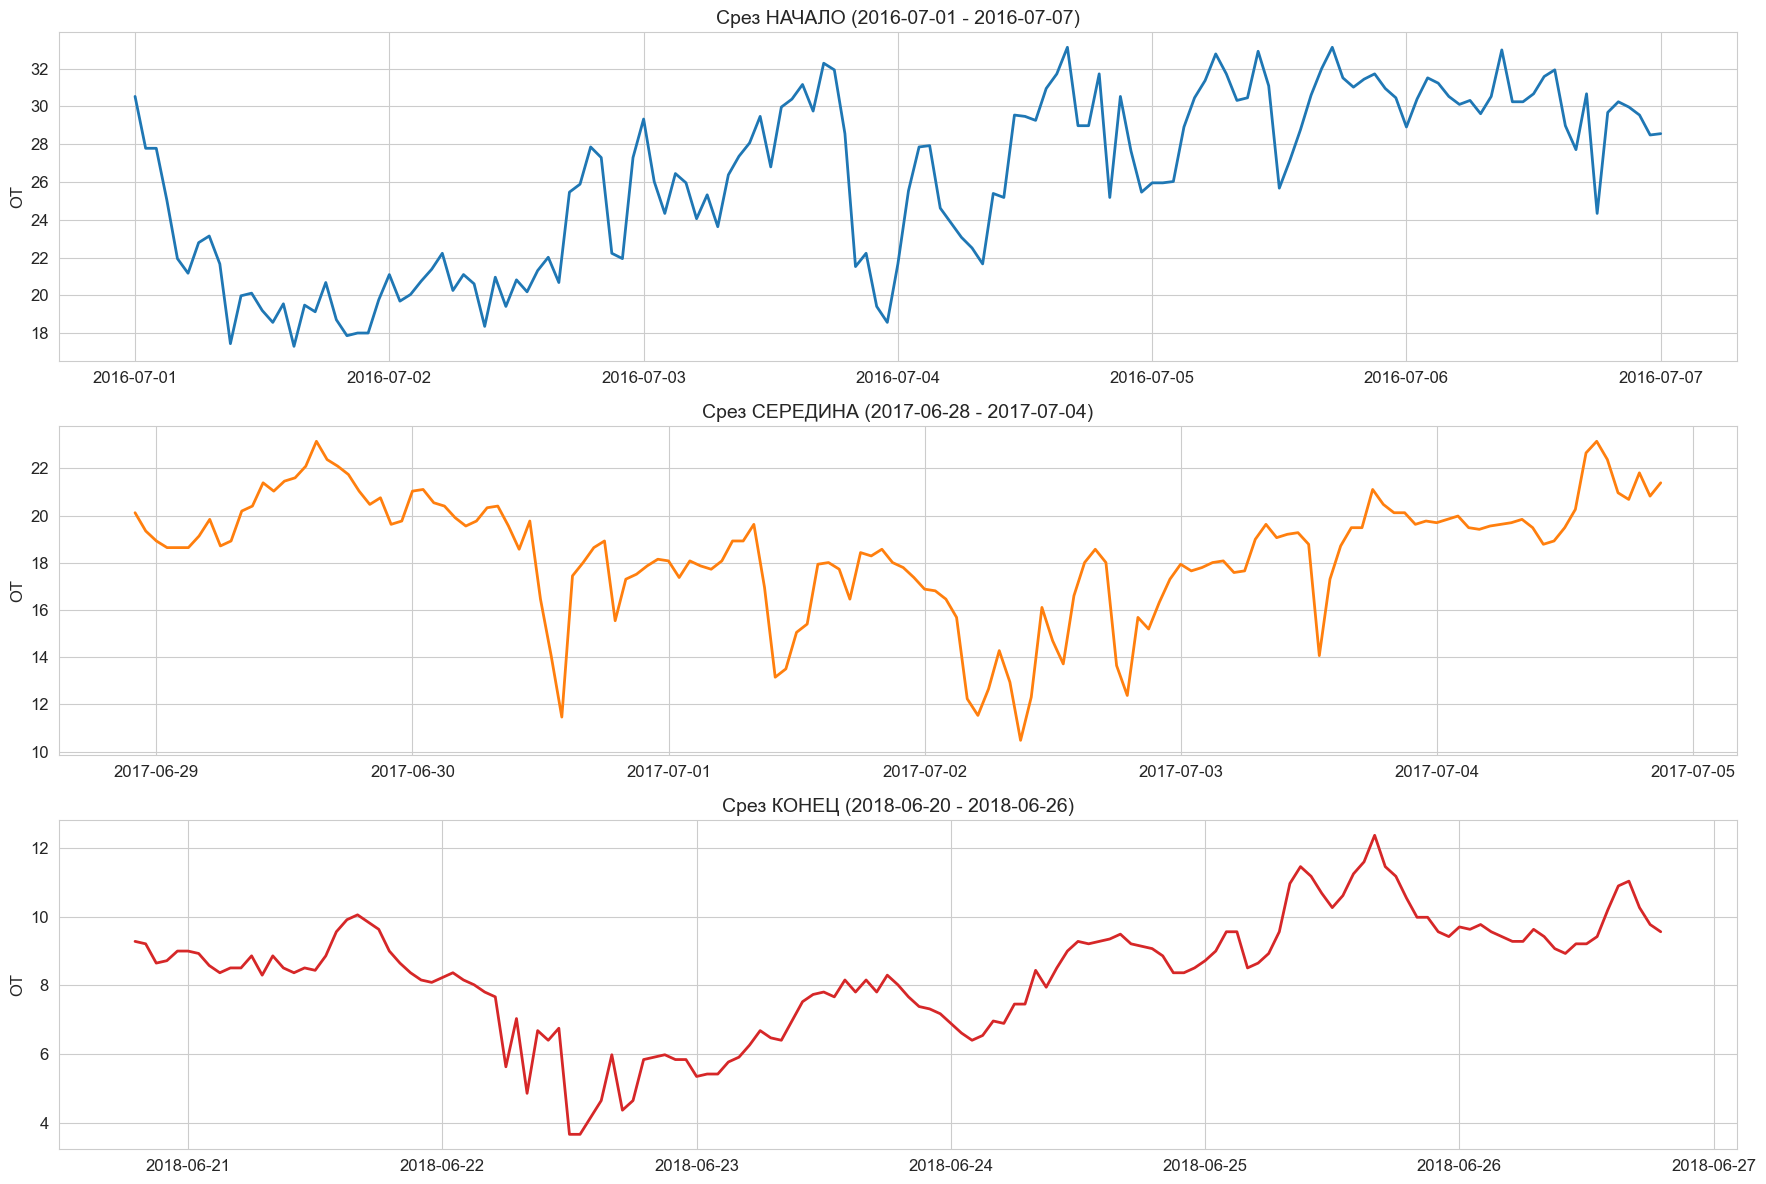

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Настройки графиков
plt.rcParams['figure.figsize'] = (15, 6)
sns.set_style("whitegrid")

# Загрузка данных
df = pd.read_csv('data_for_ikm/ETTh1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')


# 1. ВИЗУАЛИЗАЦИЯ: 3 НЕДЕЛЬНЫХ СРЕЗА
print(" Анализ 3 недельных срезов для целевой переменной OT")

start_date = df.index.min()
end_date = df.index.max()
mid_date = start_date + (end_date - start_date) / 2

df_start = df.loc[start_date : start_date + pd.Timedelta(days=6)]
df_mid   = df.loc[mid_date : mid_date + pd.Timedelta(days=6)]
df_end   = df.loc[end_date - pd.Timedelta(days=6) : end_date]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 12))

axes[0].plot(df_start.index, df_start['OT'], color='tab:blue', linewidth=2)
axes[0].set_title(f'Срез НАЧАЛО ({df_start.index.min().date()} - {df_start.index.max().date()})', fontsize=14)
axes[0].set_ylabel('OT')

axes[1].plot(df_mid.index, df_mid['OT'], color='tab:orange', linewidth=2)
axes[1].set_title(f'Срез СЕРЕДИНА ({df_mid.index.min().date()} - {df_mid.index.max().date()})', fontsize=14)
axes[1].set_ylabel('OT')

axes[2].plot(df_end.index, df_end['OT'], color='tab:red', linewidth=2)
axes[2].set_title(f'Срез КОНЕЦ ({df_end.index.min().date()} - {df_end.index.max().date()})', fontsize=14)
axes[2].set_ylabel('OT')

plt.tight_layout()
plt.show()


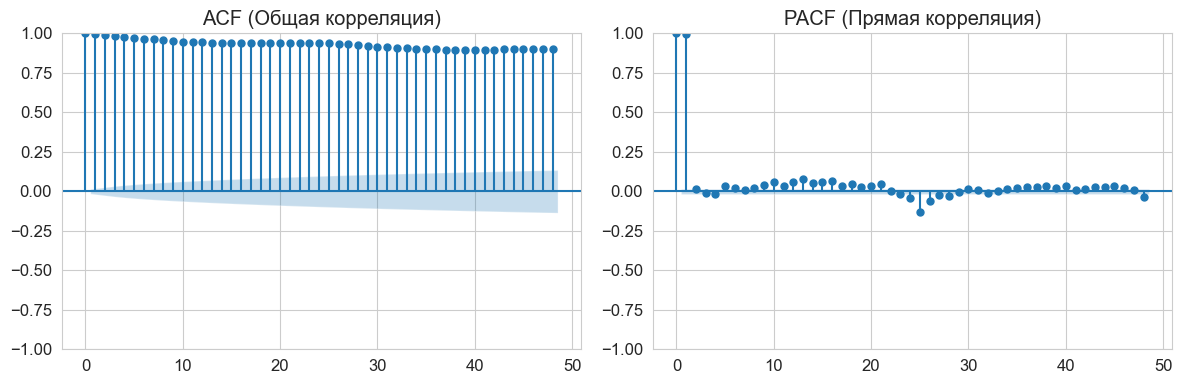

In [5]:
# 2. ACF и PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. ACF (Автокорреляция)
plot_acf(df['OT'].dropna(), ax=axes[0], lags=48, title='ACF (Общая корреляция)')

# 2. PACF (Частичная автокорреляция)
plot_pacf(df['OT'].dropna(), ax=axes[1], lags=48, title='PACF (Прямая корреляция)')

plt.tight_layout()
plt.show()


In [6]:
# 3. ТЕСТ ДИКИ-ФУЛЛЕРА
print("\nТест Дики-Фуллера на стационарность")
result_adf = adfuller(df['OT'].dropna())
p_value = result_adf[1]
print(f"Признак OT: p-value = {p_value:.5f}")
if p_value < 0.05:
    print("Вывод: Ряд OT СТАЦИОНАРЕН (по среднему значению)")
else:
    print("Вывод: Ряд OT НЕСТАЦИОНАРЕН") 


Тест Дики-Фуллера на стационарность
Признак OT: p-value = 0.00830
Вывод: Ряд OT СТАЦИОНАРЕН (по среднему значению)



Анализ выбросов для OT
Найдено выбросов в OT: 471 (это 2.70% данных)
Границы нормальности: нижняя = -9.71, верхняя = 34.75


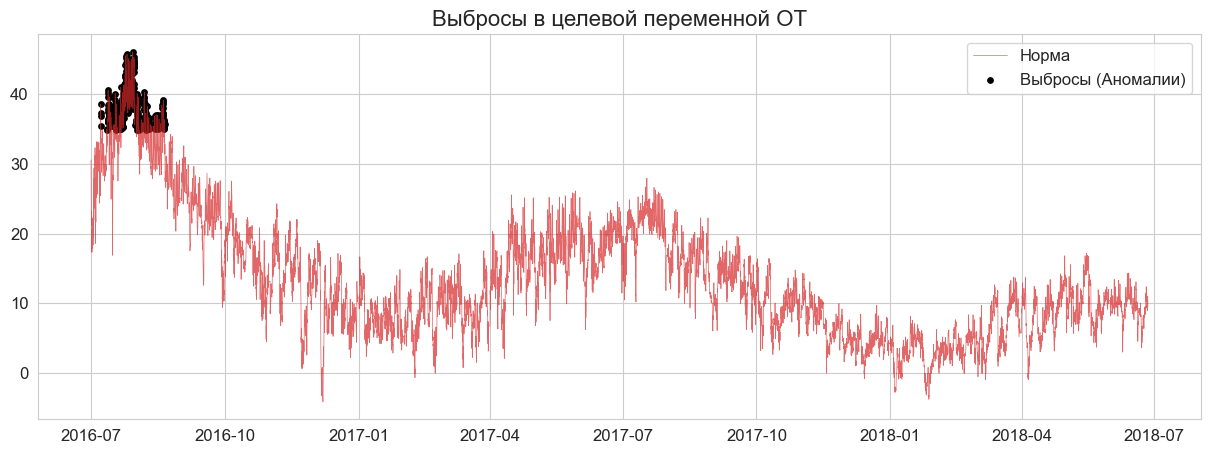

In [7]:
# 4. ПОИСК ВЫБРОСОВ
print("\nАнализ выбросов для OT")
Q1 = df['OT'].quantile(0.25)
Q3 = df['OT'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (df['OT'] < lower_bound) | (df['OT'] > upper_bound)
num_outliers = outliers_mask.sum()
print(f"Найдено выбросов в OT: {num_outliers} (это {num_outliers / len(df) * 100:.2f}% данных)")
print(f"Границы нормальности: нижняя = {lower_bound:.2f}, верхняя = {upper_bound:.2f}")

plt.figure(figsize=(15, 5))
plt.plot(df.index, df['OT'], color='tab:red', linewidth=0.5, alpha=0.7, label='Норма')
plt.scatter(df.index[outliers_mask], df.loc[outliers_mask, 'OT'], color='black', s=15, label='Выбросы (Аномалии)')
plt.title('Выбросы в целевой переменной OT', fontsize=16)
plt.legend()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_2224\3938194467.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_name', y='OT', data=df, ax=axes[0], order=day_names.values(), palette='Set2')


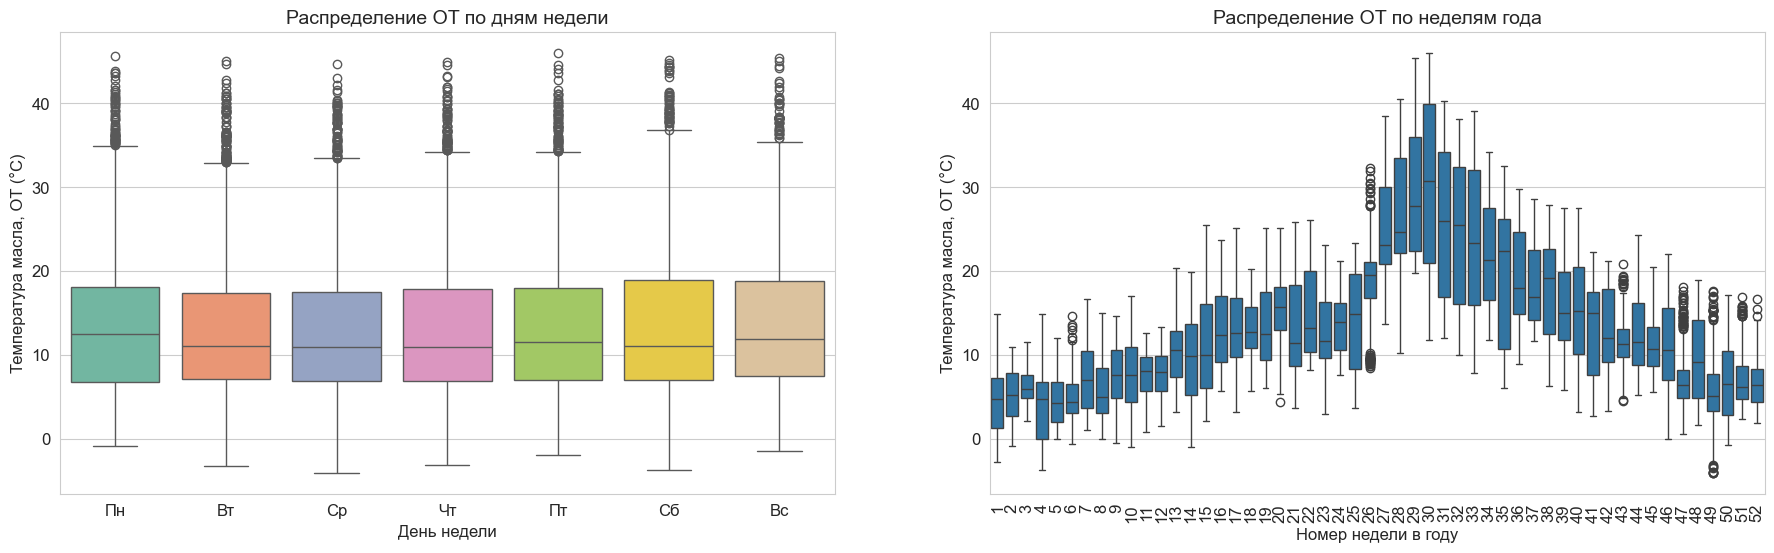

In [8]:
# 5. БОКСПЛОТЫ (Дни/Недели) + PACF
# Извлекаем признаки времени
df['dayofweek'] = df.index.dayofweek
df['week'] = df.index.isocalendar().week.astype(int)
day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
df['day_name'] = df['dayofweek'].map(day_names)

fig, axes = plt.subplots(1, 2, figsize=(22, 6))

# boxplot По дням недели
sns.boxplot(x='day_name', y='OT', data=df, ax=axes[0], order=day_names.values(), palette='Set2')
axes[0].set_title('Распределение OT по дням недели', fontsize=14)
axes[0].set_xlabel('День недели', fontsize=12)
axes[0].set_ylabel('Температура масла, OT (°C)', fontsize=12)

# boxplot По неделям года
sns.boxplot(x='week', y='OT', data=df, ax=axes[1], color='tab:blue')
axes[1].set_title('Распределение OT по неделям года', fontsize=14)
axes[1].set_xlabel('Номер недели в году', fontsize=12)
axes[1].set_ylabel('Температура масла, OT (°C)', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)


HULL    3.925438
HUFL    3.627881
MULL    3.410084
MUFL    2.974283
LUFL    1.185541
LULL    0.346473
Name: OT, dtype: float64

Корреляция целевой переменной OT с остальными признаками:
HULL    0.224354
MULL    0.220004
LUFL    0.118836
LULL    0.067455
HUFL    0.059916
MUFL    0.050854
Name: OT, dtype: float64


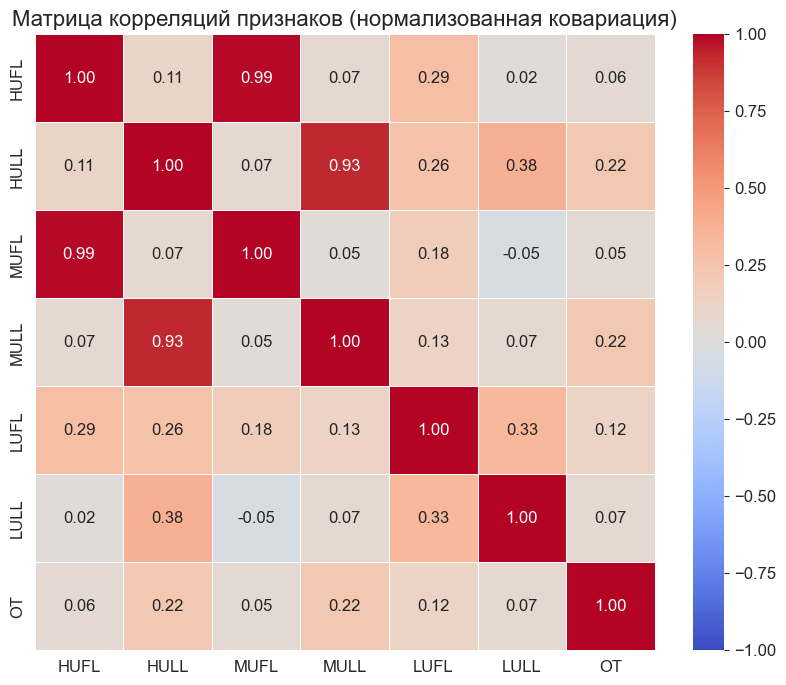

In [9]:
# 6. АНАЛИЗ КОВАРИАЦИИ И КОРРЕЛЯЦИИ
# Считаем матрицы
# Удаляем строковые колонки перед расчетом, если они еще остались
df_numeric = df.drop(columns=['day_name', 'dayofweek', 'week'], errors='ignore')
cov_matrix = df_numeric.cov()
corr_matrix = df_numeric.corr()

cov_with_ot = cov_matrix['OT'].drop('OT').sort_values(ascending=False)
print(cov_with_ot)

print("\nКорреляция целевой переменной OT с остальными признаками:")
corr_with_ot = corr_matrix['OT'].drop('OT').sort_values(ascending=False)
print(corr_with_ot)

# Визуализация: Тепловая карта корреляций (визуально понятнее, чем ковариация)
plt.figure(figsize=(10, 8))
# Используем корреляцию, так как она нормализована и легче читается
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, 
            vmin=-1, vmax=1, center=0)
plt.title('Матрица корреляций признаков (нормализованная ковариация)', fontsize=16)
plt.show()

# Промежуточные выводы
1. У ряда нет сезонности судя по срезам из 3 различных промежутков
2. Есть долгосрочная память, температура долго будет спадать - ряд инерционный
3. Ряд стационарный и есть аномальный скачок в начале, возможно тестовый прогон под нагрузкой с начала отслеживания

# 2.2 Предобработка

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Загрузка данных
df = pd.read_csv('data_for_ikm/ETTh1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')


# 1. ОБРАБОТКА ВЫБРОСОВ

print("1. Обработка выбросов")
# Используем IQR для всех колонок, чтобы очистить данные
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Находим аномалии
    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    num_outliers = outliers_mask.sum()
    
    if num_outliers > 0:
        # Заменяем аномалии на NaN
        df.loc[outliers_mask, col] = np.nan
        # Интерполируем (заполняем пустоты линейной интерполяцией от соседей)
        df[col] = df[col].interpolate(method='linear')
        # Если NaN остались в самом начале/конце, заполняем ближайшим значением
        df[col] = df[col].bfill().ffill()
        print(f"Столбец {col}: сглажено {num_outliers} выбросов")

print("Выбросы успешно интерполированы!\n")



# 2. КОДИРОВАНИЕ ВРЕМЕННЫХ ПРИЗНАКОВ 
# Извлекаем час и день недели
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

# Превращаем в циклы (sin/cos), чтобы 23:00 и 00:00 были рядом, а не на расстоянии 23
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

# Удаляем исходные колонки, они больше не нужны
df = df.drop(['hour', 'dayofweek'], axis=1)
print("Добавлены циклические признаки: hour_sin, hour_cos, dayofweek_sin, dayofweek_cos\n")



# 3. НОРМАЛИЗАЦИЯ
print("3. Масштабирование данных")
# Сохраняю целевую переменную отдельно для удобства обратного преобразования при оценке модели
target_col = 'OT'
feature_cols = [col for col in df.columns if col != target_col]

# Скейлеры
scaler_features = StandardScaler()
scaler_target = StandardScaler()


df[feature_cols] = scaler_features.fit_transform(df[feature_cols])
df[[target_col]] = scaler_target.fit_transform(df[[target_col]])

print("Все признаки отмасштабированы.\n")

# финальный вид датасета
print("Финальная структура датасета:")
print(df.head())
print("\nОписательная статистика после предобработки:")
print(df.describe().round(2))

# СОХРАНЕНИЕ СКЕЙЛЕРОВ ДЛЯ БУДУЩЕГО (чтобы вернуть реальные значения OT)
import joblib
joblib.dump(scaler_features, 'scaler_features.pkl')
joblib.dump(scaler_target, 'scaler_target.pkl')
print("\nСкейлеры сохранены в файлы .pkl")

1. Обработка выбросов
Столбец HUFL: сглажено 1824 выбросов
Столбец HULL: сглажено 51 выбросов
Столбец MUFL: сглажено 2005 выбросов
Столбец MULL: сглажено 78 выбросов
Столбец LUFL: сглажено 561 выбросов
Столбец LULL: сглажено 1714 выбросов
Столбец OT: сглажено 471 выбросов
Выбросы успешно интерполированы!

Добавлены циклические признаки: hour_sin, hour_cos, dayofweek_sin, dayofweek_cos

3. Масштабирование данных
Все признаки отмасштабированы.

Финальная структура датасета:
                         HUFL      HULL      MUFL      MULL      LUFL  \
date                                                                    
2016-07-01 00:00:00 -0.533749 -0.113546 -0.931170 -0.236717  1.189563   
2016-07-01 01:00:00 -0.561449 -0.080542 -0.956605 -0.256880  1.128277   
2016-07-01 02:00:00 -0.672251 -0.245563 -1.007236 -0.296645  0.761561   
2016-07-01 03:00:00 -0.686102 -0.146551 -1.007236 -0.276483  0.791702   
2016-07-01 04:00:00 -0.630700 -0.146551 -0.956605 -0.236717  0.852989   

           

# После обработки датасета у меня стало 11 признаков:
1. HUFL, HULL, MUFL, MULL, LUFL, LULL — Отмасштабированные исходные 6 признаков нагрузки 
2. OT — Целевая переменная
3. hour_sin, hour_cos — Циклическое кодирование часа суток для моделей, так обозначается то, что после 23:00 идёт 00:00
4. dayofweek_sin, dayofweek_cos — Циклическое кодирование дня недели. Аналогичная логика с 3 пунктом
Циклические признаки были переведены в радианы. Таким образом мы отразили цикличность суток.

## Также я отмасштабировал значения признаков и удалил выбросы (из начального перепада в большинстве своём)

# 3: Извлечение признаков

In [11]:
import pandas as pd
import numpy as np

target = 'OT'

# 1. ЛАГОВЫЕ ПРИЗНАКИ (Прошлые значения)
print("1. Создание лаговых признаков")
# Так как сезонность суточная слабая, берем ближайшие часы и сутки (24 часа)
# Также берем 48 часов (2 дня) из-за большой инерционности ряда
lags = [1, 2, 3, 6, 12, 24, 48]

for lag in lags:
    df[f'{target}_lag_{lag}'] = df[target].shift(lag)

print(f"Добавлены лаги: {lags}")


# 2. СКОЛЬЗЯЩИЕ СТАТИСТИКИ (Средняя величина за прошлое время)
print("\n--- 2. Создание скользящих статистик ---")
# Скользящее среднее (Moving Average) и скользящее стандартное отклонение
# Окна: 6 часов (полдня), 24 часа (сутки)
windows = [6, 24]

for window in windows:
    # shift(1) обязательна! Иначе мы дадим модели текущее среднее, в которое входит текущий час (утечка данных)
    df[f'{target}_rolling_mean_{window}'] = df[target].rolling(window=window).mean().shift(1)
    df[f'{target}_rolling_std_{window}'] = df[target].rolling(window=window).std().shift(1)

print(f"Добавлены скользящие средние и СКО для окон: {windows}")

# 3. FFT FEATURES (Признаки Фурье)
print("\n3. Извлечение признаков с помощью FFT")
# FFT переводит ряд из временного пространства в частотное.
# Брать буду топ-3 самых сильных волн, добавляю их как признаки

def get_fft_features(series, n_top=3):
    # Убираем NaN
    series_clean = series.dropna()
    if len(series_clean) < 4:
        return [np.nan] * n_top * 2
    
    # Применяем FFT
    fft_vals = np.fft.fft(series_clean)
    # Берем амплитуды (сила частоты)
    amplitudes = np.abs(fft_vals)[:len(fft_vals)//2]
    
    # Индексы самых сильных частот (Нулевая частота - константа, пропускаем)
    top_indices = np.argsort(amplitudes[1:])[-n_top:] + 1
    
    # Возвращаем амплитуды и фазы самых сильных частот
    features = []
    for idx in top_indices:
        features.append(amplitudes[idx]) # Сила сигнала
        features.append(np.angle(fft_vals[idx])) # Фаза сигнала
    return features

# Применяем FFT на скользящем окне в 24 часа (чтобы ловить локальные частоты)
fft_window = 24
n_top_freqs = 2 # Возьмем 2 главные частоты (4 признака: 2 амплитуды + 2 фазы)

# Создаем колонки заранее
fft_cols = [f'FFT_amp_{i+1}' for i in range(n_top_freqs)] + [f'FFT_phase_{i+1}' for i in range(n_top_freqs)]
for col in fft_cols:
    df[col] = np.nan

# Скользящее применение FFT
for i in range(fft_window, len(df)):
    window_data = df[target].iloc[i-fft_window:i]
    fft_feats = get_fft_features(window_data, n_top=n_top_freqs)
    df.iloc[i, df.columns.get_indexer(fft_cols)] = fft_feats

print(f"Добавлены FFT признаки (окно {fft_window}ч, топ-{n_top_freqs} частоты): {fft_cols}")


# 4. ФИНАЛЬНАЯ ОЧИСТКА ОТ NaN
# Из-за лагов и скользящих окон в начале датасета появились NaN.
initial_len = len(df)
df = df.dropna()
print(f"\nУдалено строк с NaN после извлечения признаков: {initial_len - len(df)}")
print(f"Финальный размер датасета: {df.shape}")

# Посмотрим на новые колонки
print("\nНовые признаки в датасете:")
print(df.columns.tolist())

1. Создание лаговых признаков
Добавлены лаги: [1, 2, 3, 6, 12, 24, 48]

--- 2. Создание скользящих статистик ---
Добавлены скользящие средние и СКО для окон: [6, 24]

3. Извлечение признаков с помощью FFT
Добавлены FFT признаки (окно 24ч, топ-2 частоты): ['FFT_amp_1', 'FFT_amp_2', 'FFT_phase_1', 'FFT_phase_2']

Удалено строк с NaN после извлечения признаков: 48
Финальный размер датасета: (17372, 26)

Новые признаки в датасете:
['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'OT_lag_1', 'OT_lag_2', 'OT_lag_3', 'OT_lag_6', 'OT_lag_12', 'OT_lag_24', 'OT_lag_48', 'OT_rolling_mean_6', 'OT_rolling_std_6', 'OT_rolling_mean_24', 'OT_rolling_std_24', 'FFT_amp_1', 'FFT_amp_2', 'FFT_phase_1', 'FFT_phase_2']


После этого шага были добавлены следующие признаки для модели:
1. Лаговые признаки - нужны для того чтобы модель понимала что было до этого
2. Скользящиие средние - Для значения и отклонения целевого признака
3. FFT признаки - Раскрываем скрытые свойства сигнала, показывая амплитуду и частоту самой сильной волны после преобразования Фурье

# 4.1 Моделирование RF

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib


# 1. ПОДГОТОВКА ДАННЫХ

# Отделяем целевой признак
target_col = 'OT'
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols].values
y = df[target_col].values


split_idx = int(len(df) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Выводим размеры выборок
print(f"Размер обучающей выборки: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Размер тестовой выборки: X_test {X_test.shape}, y_test {y_test.shape}")

# ВНИМАНИЕ: Наши y_scaled (от -1 до 1 примерно). Для понимания метрик в градусах,
# сделаем обратное преобразование (inverse_transform) для тестовой выборки.
# Скейлер мы сохранили на Этапе 2.
try:
    scaler_target = joblib.load('scaler_target.pkl')
    y_test_real = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()
    print("Скейлер целевой переменной загружен. Метрики будут в реальных градусах.")
except:
    y_test_real = y_test
    print("Скейлер не найден. Метрики будут в отмасштабированных единицах.")


# 2. ОБУЧЕНИЕ RANDOM FOREST
print("\nОбучение Random Forest")

# Инициализируем модель. 
# n_jobs=-1 - используем все ядра процессора для ускорения
# max_depth=15 - ограничил глубину, чтобы не модель не переобучилась
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

# Обучаем модель
rf_model.fit(X_train, y_train)
print("Обучение Random Forest завершено!")

# Делаем предсказания на тестовой выборке
y_pred_rf_scaled = rf_model.predict(X_test)

# Обратно преобразуем предсказания в градусы Цельсия
try:
    y_pred_rf_real = scaler_target.inverse_transform(y_pred_rf_scaled.reshape(-1, 1)).flatten()
except:
    y_pred_rf_real = y_pred_rf_scaled

# 3. ОЦЕНКА МОДЕЛИ (Метрики)
print("\nОценка Random Forest")

# MSE (Mean Squared Error) - среднеквадратичная ошибка (штрафует за большие ошибки)
# MAE (Mean Absolute Error) - средняя абсолютная ошибка (в среднем ошибаемся на X градусов)
mse_rf = mean_squared_error(y_test_real, y_pred_rf_real)
mae_rf = mean_absolute_error(y_test_real, y_pred_rf_real)

print(f"Random Forest MSE: {mse_rf:.4f}")
print(f"Random Forest MAE: {mae_rf:.4f} (градусов Цельсия)")

# Сохраним результаты для финального сравнения
results = {
    'Random Forest': {'MSE': mse_rf, 'MAE': mae_rf}
}

Размер обучающей выборки: X_train (13897, 25), y_train (13897,)
Размер тестовой выборки: X_test (3475, 25), y_test (3475,)
Скейлер целевой переменной загружен. Метрики будут в реальных градусах.

Обучение Random Forest
Обучение Random Forest завершено!

Оценка Random Forest
Random Forest MSE: 0.4526
Random Forest MAE: 0.4738 (градусов Цельсия)


Очень хорошая точность для простой модели, так как у ряда больщая инерция, поэтому предсказать очень легко.

# 4.2 Используем нейросети

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import matplotlib.pyplot as plt

# Загружаем скейлер для возврата в градусы Цельсия
scaler_target = joblib.load('scaler_target.pkl')


# 1. КЛАСС ДАТАСЕТА 
class TimeSeriesDataset(Dataset):
    """
    Класс Dataset для генерации окон временного ряда "на лету" из 11 практики
    """
    def __init__(self, X, y, lookback):
        """
        Args:
            X: исходная матрица признаков (numpy array)
            y: исходный вектор целевой переменной (numpy array)
            lookback: размер окна (в часах) для предсказания
        """
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)
        self.lookback = lookback
        
    def __len__(self):
        """Возвращает количество доступных обучающих окон."""
        return len(self.X) - self.lookback
        
    def __getitem__(self, idx):
        """
        Возвращает один элемент по индексу idx.
        """
        # Берем окно признаков: от idx до idx + lookback
        X_seq = self.X[idx : idx + self.lookback] 
        # Берем цель: значение в момент idx + lookback
        y_val = self.y[idx + self.lookback]
        return X_seq, y_val


# 2. АРХИТЕКТУРЫ НЕЙРОСЕТЕЙ 
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                            num_layers=num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        x, _ = self.lstm(x)
        # Берем выход только с последнего шага последовательности
        x = self.linear(x[:, -1, :])
        return x

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, 
                          num_layers=num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        x, _ = self.gru(x)
        x = self.linear(x[:, -1, :])
        return x


# 3. ФУНКЦИЯ ОБУЧЕНИЯ С EARLY STOPPING (Из практики)
def train_model_with_dataset(model, train_dataset, test_dataset, n_epochs, patience=5, batch_size=64):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    
    train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)
    
    best_loss = float('inf')
    not_improve_epochs = 0
    
    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred.squeeze(), y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        # Валидация на каждой эпохе
        model.eval()
        with torch.no_grad():
            test_preds = []
            test_targets = []
            for X_batch, y_batch in test_loader:
                test_preds.append(model(X_batch).squeeze())
                test_targets.append(y_batch)
            
            y_pred_test = torch.cat(test_preds)
            y_test_full = torch.cat(test_targets)
            test_rmse = torch.sqrt(loss_fn(y_pred_test, y_test_full)).item()
            
        # Проверка улучшения метрики
        if test_rmse < best_loss:
            best_loss = test_rmse 
            not_improve_epochs = 0 
            # Сохраняем лучшую модель
            best_model_state = model.state_dict()
            if (epoch+1) % 5 == 0:
                print(f"Epoch {epoch+1}: test RMSE {test_rmse:.4f} [BEST]")
        else:
            not_improve_epochs += 1 
            if (epoch+1) % 5 == 0:
                print(f"Epoch {epoch+1}: test RMSE {test_rmse:.4f} (no improvement: {not_improve_epochs}/{patience})")
            
        # Ранняя остановка
        if not_improve_epochs >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
    # Загружаем веса лучшей модели
    model.load_state_dict(best_model_state)
    return model


# 4. ЗАПУСК: Подготовка данных и Обучение

#  X и y мы получили на этапе Random Forest
# X = df[feature_cols].values, y = df[target_col].values

lookback = 24 # Смотрим на 24 часа назад
input_size = X.shape[1] # 25 признаков

# Деление хронологическое (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Создание датасетов
train_dataset = TimeSeriesDataset(X_train, y_train, lookback=lookback)
test_dataset = TimeSeriesDataset(X_test, y_test, lookback=lookback)

print(f"Размер обучающей выборки (окон): {len(train_dataset)}")
print(f"Размер тестовой выборки (окон): {len(test_dataset)}")

# --- Обучение LSTM ---
print("\n--- Обучение LSTM ---")
lstm_model = LSTMModel(input_size=input_size, hidden_size=64, num_layers=2)
lstm_model = train_model_with_dataset(lstm_model, train_dataset, test_dataset, n_epochs=30, patience=5)

# --- Обучение GRU ---
print("\n--- Обучение GRU ---")
gru_model = GRUModel(input_size=input_size, hidden_size=64, num_layers=2)
gru_model = train_model_with_dataset(gru_model, train_dataset, test_dataset, n_epochs=30, patience=5)


# 5. ОЦЕНКА И СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
def evaluate_model(model, test_dataset, model_name):
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    model.eval()
    preds = []
    targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds.append(model(X_batch).squeeze().numpy())
            targets.append(y_batch.numpy())
            
    y_pred_scaled = np.concatenate(preds)
    y_test_scaled = np.concatenate(targets)
    
    # Обратно в градусы Цельсия
    y_pred_real = scaler_target.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_test_real = scaler_target.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
    
    mse = mean_squared_error(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    
    print(f"\n{model_name} Результаты:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f} (градусов Цельсия)")
    
    return mse, mae, y_pred_real, y_test_real

mse_lstm, mae_lstm, y_pred_lstm, y_test_real = evaluate_model(lstm_model, test_dataset, "LSTM")
mse_gru, mae_gru, y_pred_gru, _ = evaluate_model(gru_model, test_dataset, "GRU")

# Добавляем в наш словарь результатов (который начали на этапе Random Forest)
results['LSTM'] = {'MSE': mse_lstm, 'MAE': mae_lstm}
results['GRU'] = {'MSE': mse_gru, 'MAE': mae_gru}

Размер обучающей выборки (окон): 13873
Размер тестовой выборки (окон): 3451

--- Обучение LSTM ---
Epoch 5: test RMSE 0.1226 (no improvement: 1/5)
Epoch 10: test RMSE 0.1145 (no improvement: 1/5)
Early stopping triggered at epoch 14

--- Обучение GRU ---
Epoch 5: test RMSE 0.1111 [BEST]
Epoch 10: test RMSE 0.1129 (no improvement: 3/5)
Early stopping triggered at epoch 12

LSTM Результаты:
MSE: 0.9247
MAE: 0.7005 (градусов Цельсия)

GRU Результаты:
MSE: 0.8580
MAE: 0.6677 (градусов Цельсия)


# 5 Сравнение моделей

--- Сравнительная таблица моделей ---
                  MSE     MAE
Модель                       
Random Forest  0.4526  0.4738
GRU            0.8580  0.6677
LSTM           0.9247  0.7005

Лучшая модель по метрике MAE: Random Forest


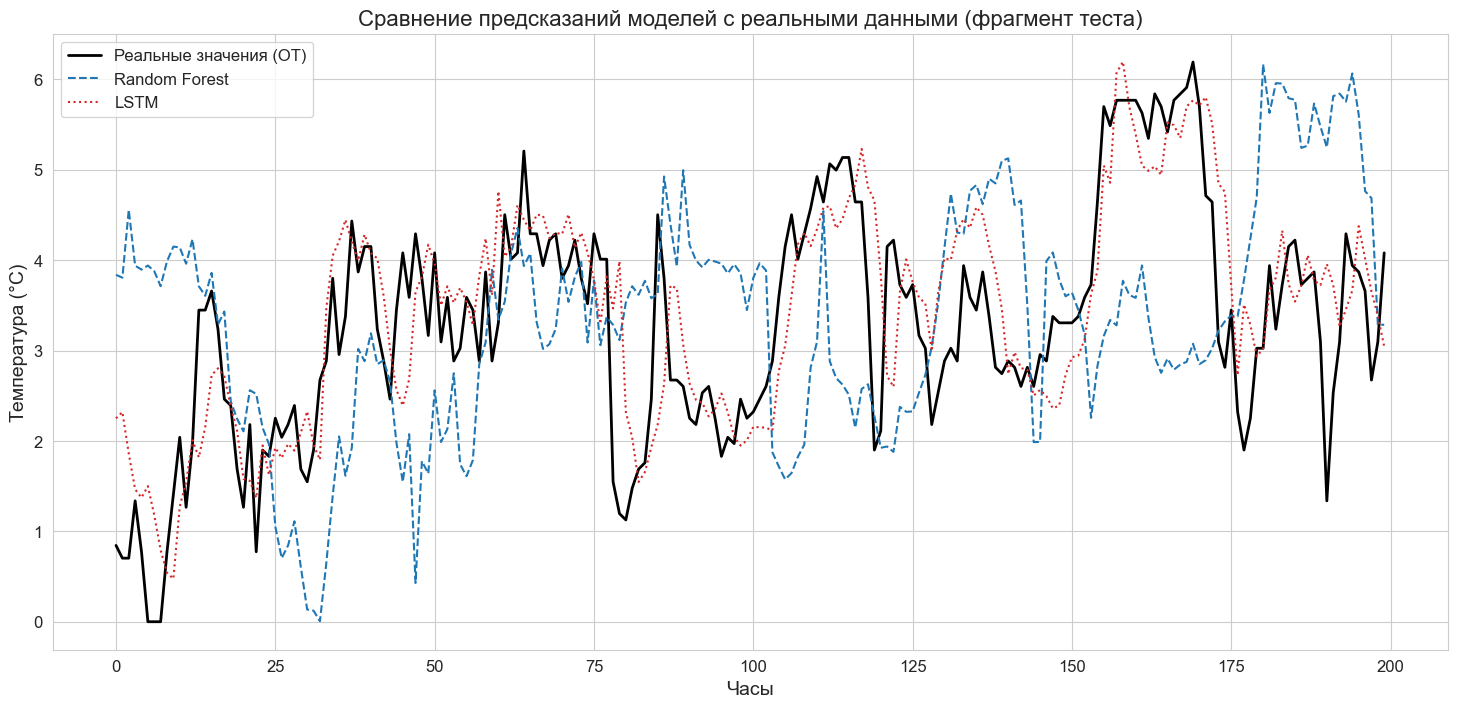

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. СРАВНИТЕЛЬНАЯ ТАБЛИЦА
print("--- Сравнительная таблица моделей ---")

results_df = pd.DataFrame(results).T
results_df.index.name = 'Модель'

results_df = results_df.sort_values(by='MAE')

results_df = results_df.round(4)

print(results_df)
print("\nЛучшая модель по метрике MAE:", results_df.index[0])


# 2. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ (Графики)
# Построим график, чтобы визуально оценить, как модели предск   азывают
# Возьмем кусок тестовой выборки (последние 200 часов = ~8 дней)

plot_len = 200
hours = range(plot_len)

plt.figure(figsize=(18, 8))

# Реальные значения
plt.plot(hours, y_test_real[:plot_len], color='black', linewidth=2, label='Реальные значения (OT)')

# Предсказания Random Forest
# (y_pred_rf_real остался у нас в памяти с этапа RF)
plt.plot(hours, y_pred_rf_real[:plot_len], color='tab:blue', linestyle='--', label='Random Forest')

# Предсказания LSTM
plt.plot(hours, y_pred_lstm[:plot_len], color='tab:red', linestyle=':', label='LSTM')

plt.title('Сравнение предсказаний моделей с реальными данными (фрагмент теста)', fontsize=16)
plt.xlabel('Часы', fontsize=14)
plt.ylabel('Температура (°C)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Вывод
Основываясь на таблице и графиках, вот подробный анализ причин различий в качестве моделей:

1. Определение лучшей модели
Победителем стала модель Random Forest, показавшая среднюю абсолютную ошибку (MAE) всего 0.4738 градуса Цельсия. Нейросетевые архитектуры (LSTM и GRU) показали близкие друг к другу результаты (MAE ~0.68-0.72 °C), но уступили классическому алгоритму около 45% по качеству ошибки. Хотя и диапозон значений в пределах единицы

2. Объяснение причин различий в качестве
Почему Random Forest победил? 
Признак **OT_lag_1:** Датасет ETTh1 обладает высокой инерционностью (автокорреляция плавно спадала). Это значит, что температура в текущий час (t) почти равна температуре в предыдущий час (t−1). Алгоритм просто "смотрит" на колонку OT_lag_1 и делает предсказание, близкое к ней, добавляя микро-поправки на основе других признаков.
    Устойчивость к шуму: Random Forest ансамблирует 100 деревьев, что отлично сглаживает случайные колебания и те самые аномалии,   которые мы интерполировали.
    Идеальное попадание в фичи: На этапе Feature Engineering мы вручную "разложили" временной ряд на понятные компоненты (тренды через rolling_mean, память через lag, циклы через sin/cos). Для классического ML это всё, что нужно для идеальной работы.

Почему LSTM и GRU отстали?
Разница в подходе к данным: Нейросети RNN-типа не видят "готовые" лаги напрямую как отдельные колонки. Они должны сами научиться извлекать зависимость yt​=f(yt−1) через свои скрытые состояния (hidden states). Обучить нейросеть так же стабильно опираться на последний шаг последовательности, как это делает RF, сложнее.

Основные причины: Объем данных, Характер данных (отсутствие сложной сезонности)

# Общий вывод по проекту
Для инерционных временных рядов без ярко выраженной сложной сезонности (как в датасете ETTh1) подход "грамотный Feature Engineering + классическая модель (Random Forest)" оказывается более эффективным, быстрым и интерпретируемым, чем использование тяжелых нейросетевых архитектур. Нейросети (LSTM, GRU) показывают приемлемый результат (ошибка менее 1 градуса), но требуют больше времени на обучение и настройку, не давая прироста в качестве на данном датасете.